# Thailand: GDP per Capita (current US$), 1990-2019

Same simple flow as the urban population chart: load the World Bank file, choose Thailand's data, and plot it yearly. Data runs 1990-2019, the x-axis extends to 2020, and the last point has a dot. No text labels.

**Source:** World Bank, World Development Indicators, indicator `NY.GDP.PCAP.CD` ([data.worldbank.org](https://data.worldbank.org/indicator/NY.GDP.PCAP.CD?locations=TH)).

## Step 1 - Setup

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")

## Step 2 - Upload the CSV (Colab)

In [10]:
try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    print("Not in Colab - make sure the CSV is in the working directory.")

DATA_PATH = "Thailand_gdp_percap_2015usd.csv"

Not in Colab - make sure the CSV is in the working directory.


## Step 3 - Choose Thailand's data

In [11]:
df = pd.read_csv(DATA_PATH, skiprows=4)

thailand = df[df["Country Name"] == "Thailand"]
years = [str(y) for y in range(1990, 2020)]

th = thailand[years].T.reset_index()
th.columns = ["Year", "gdp_per_capita"]
th["Year"] = th["Year"].astype(int)
th.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Year            30 non-null     int64  
 1   gdp_per_capita  30 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


## Step 4 - Plot

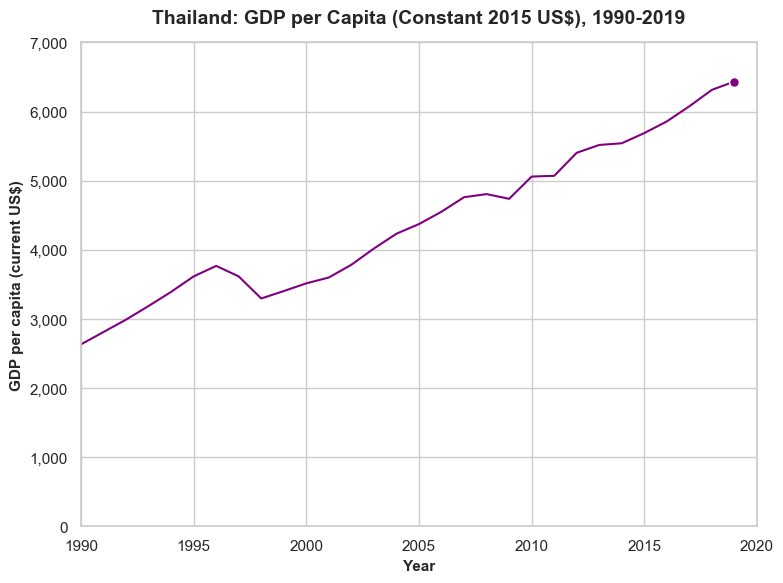

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(data=th, x="Year", y="gdp_per_capita", ax=ax,
             color="purple", linewidth=1.5)

ax.set_title("Thailand: GDP per Capita (Constant 2015 US$), 1990-2019", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Year", fontsize=11, fontweight="bold")
ax.set_ylabel("GDP per capita (current US$)", fontsize=11, fontweight="bold")
ax.set_xlim(1990, 2020)
ax.set_ylim(0,7000)
ax.set_xticks(sorted(set(list(range(1990, 2020, 5)) + [2020])))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

# dot on the last data point
last_row = th.iloc[-1]
ax.scatter([last_row["Year"]], [last_row["gdp_per_capita"]], color="purple", s=50,
           zorder=5, edgecolor="white", linewidth=1)

plt.tight_layout()
plt.savefig("thailand_gdp_per_capita.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()